# **Predctive Modelling**

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

In [13]:
# point to a file two directories above the notebook’s current working directory
file = Path.cwd().parents[1] /'data'/'processed' / 'for_visualization'/ 'superstore_data.csv' 
df = pd.read_csv(file, encoding='latin1')


In [14]:
print(file)

c:\Users\marcel\Documents\Data Analysis Projects\Superstore Sales Project\data\processed\for_visualization\superstore_data.csv


In [12]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Order Processing Time', 'Order Processing Days', 'Profit Margin',
       '%Profit Margin', 'Order Year', 'Order Quarter', 'Order Month',
       'Shipped Year', 'Shipped Quarter', 'Shipped Month',
       'Number Of Order Month', 'Number Of Shipped Month'],
      dtype='object')

# **Time series forecasting**
- Sales forecasting using Prophet
- Trend and seasonality decomposition

## **Forecast for SALES Data**
- For the next 364 days

In [13]:
sales_data = df[['Sales','Order Date']].copy()

14:29:44 - cmdstanpy - INFO - Chain [1] start processing
14:29:46 - cmdstanpy - INFO - Chain [1] done processing


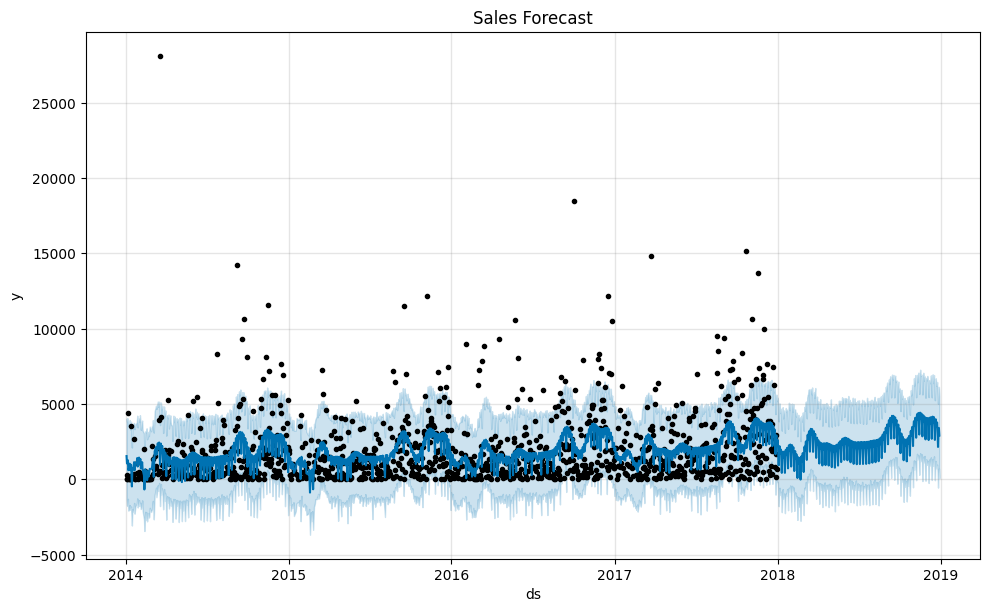

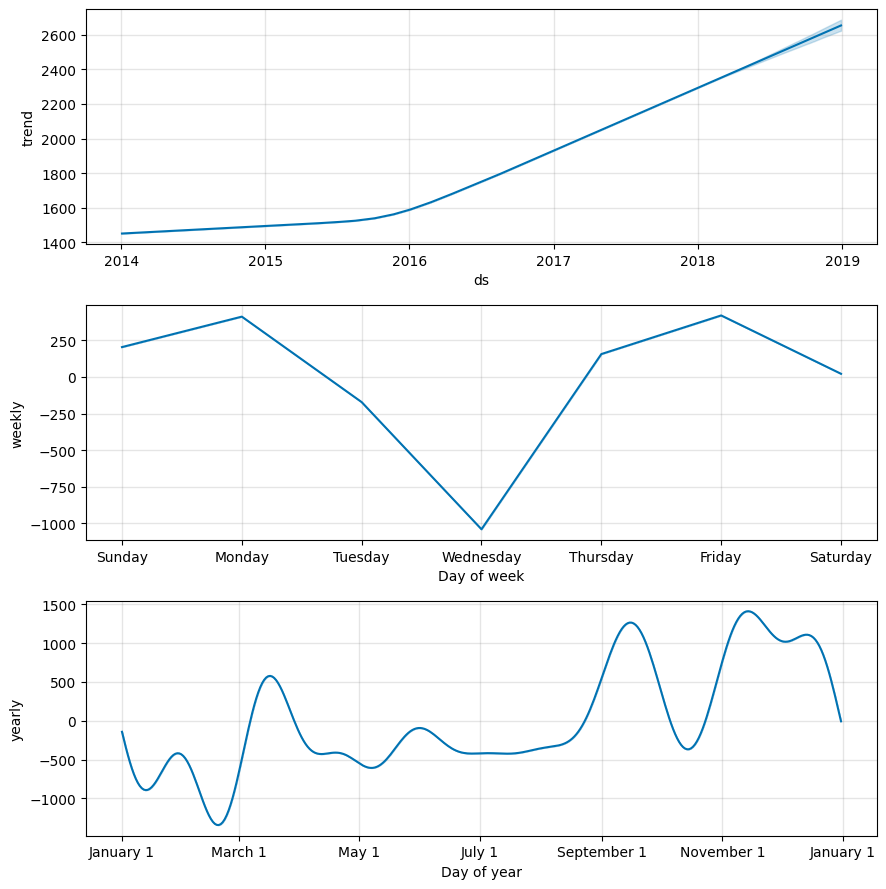

             ds         yhat  yhat_lower   yhat_upper
1596 2018-12-25  3112.483579  464.838773  5778.230232
1597 2018-12-26  2153.676295 -543.476446  5014.839616
1598 2018-12-27  3253.685778  414.023194  6023.807952
1599 2018-12-28  3416.078008  732.704720  6141.725336
1600 2018-12-29  2912.727064   94.881272  5509.036264


In [20]:
# aggregate sales by order date and get into Prophet format
prophet_df = sales_data.copy()
prophet_df['ds'] = pd.to_datetime(prophet_df['Order Date'])
prophet_df = (
    prophet_df
    .groupby('ds', as_index=False)['Sales']
    .sum()
    .rename(columns={'Sales': 'y'})
)

# fit a Prophet model on the aggregated series
sales_model = Prophet()
sales_model.fit(prophet_df)

# make a future frame and forecast
future_sales = sales_model.make_future_dataframe(periods=364)   # e.g. 364‑day horizon
sales_forecast = sales_model.predict(future_sales)

# plot the forecast and its components
sales_model.plot(sales_forecast)
plt.title("Sales Forecast")
plt.show()

sales_model.plot_components(sales_forecast)
plt.show()

# review the last rows of the prediction
print(sales_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

## **Forecast for PROFIT Data**
- For the next 364 days

In [16]:
profit_data = df[['Profit','Order Date']].copy()

14:29:09 - cmdstanpy - INFO - Chain [1] start processing
14:29:10 - cmdstanpy - INFO - Chain [1] done processing


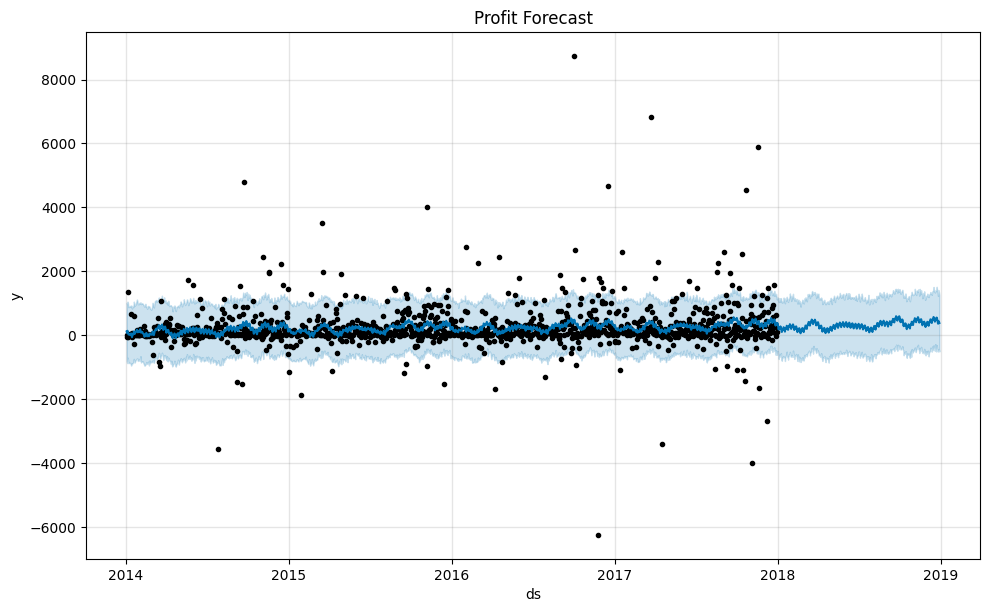

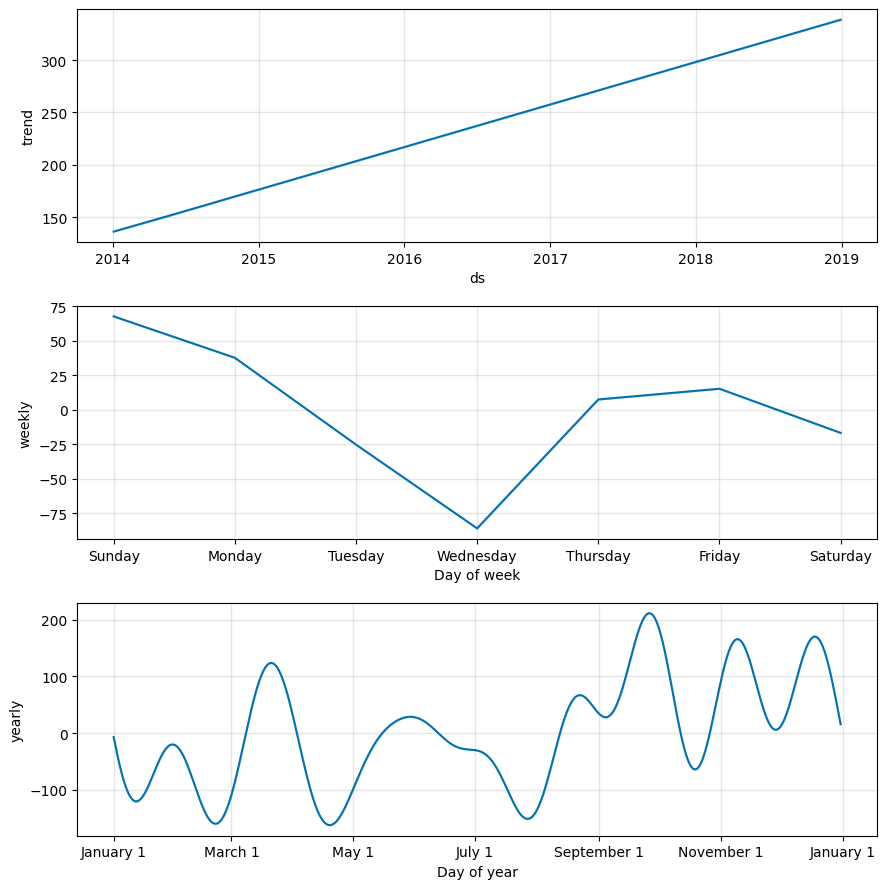

             ds        yhat  yhat_lower   yhat_upper
1596 2018-12-25  434.690248 -436.116112  1344.053579
1597 2018-12-26  359.640070 -513.234442  1228.816551
1598 2018-12-27  437.079845 -454.912664  1410.752506
1599 2018-12-28  427.973354 -448.726454  1355.604746
1600 2018-12-29  378.418698 -508.900179  1255.420140


In [19]:
# aggregate profit by order date and get into Prophet format
prophet_df = profit_data.copy()
prophet_df['ds'] = pd.to_datetime(prophet_df['Order Date'])
prophet_df = (
    prophet_df
    .groupby('ds', as_index=False)['Profit']
    .sum()
    .rename(columns={'Profit': 'y'})
)

# fit a Prophet model on the aggregated series
profit_model = Prophet()
profit_model.fit(prophet_df)

# make a future frame and forecast
future_profit = profit_model.make_future_dataframe(periods=364)   # e.g. 364‑day horizon
profit_forecast = profit_model.predict(future_profit)

# plot the forecast and its components
profit_model.plot(profit_forecast)
plt.title("Profit Forecast")
plt.show()

profit_model.plot_components(profit_forecast)
plt.show()

# review the last rows of the prediction
print(profit_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

## **Forecast for Quantity Data**
- For the next 364 days

In [21]:
quantity_data = df[['Quantity','Order Date']].copy()

# **Customer Segmentation**
- K-means clustering
- Principal Component Analysis

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


explained variance ratio (PC1, PC2): [0.53261628 0.3102977 ]


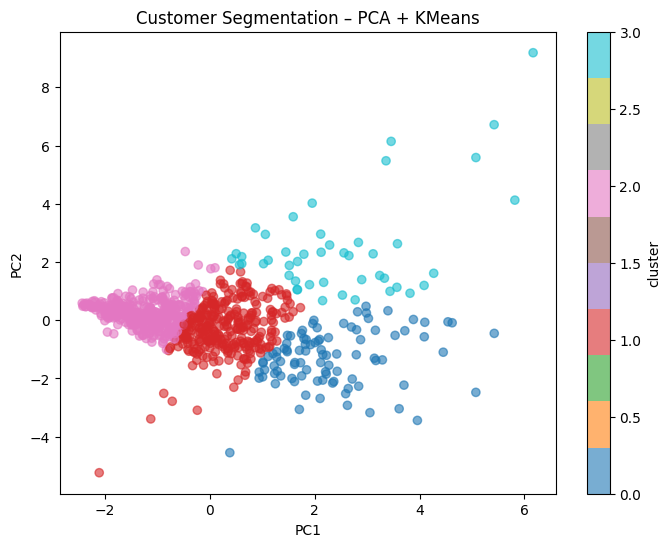

cluster
2    353
1    300
0     94
3     46
Name: count, dtype: int64


In [24]:
# pick a few numeric columns that make sense for segmentation
# aggregate them per customer so each row is a customer
cust_metrics = (
    df
    .groupby('Customer ID')[['Sales', 'Profit', 'Quantity', 'Discount']]
    .sum()
    .reset_index()
)

# scale before PCA / k‑means
scaler = StandardScaler()
X = scaler.fit_transform(cust_metrics[['Sales', 'Profit', 'Quantity', 'Discount']])

# reduce to two principal components for visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# apply k‑means on the PCA space
kmeans = KMeans(n_clusters=4, random_state=42)
cust_metrics['cluster'] = kmeans.fit_predict(X_pca)

print("explained variance ratio (PC1, PC2):", pca.explained_variance_ratio_)

# scatter plot of the two principal components coloured by cluster
plt.figure(figsize=(8, 6))
pts = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                  c=cust_metrics['cluster'], cmap='tab10', alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Customer Segmentation – PCA + KMeans')
plt.colorbar(pts, label='cluster')
plt.show()

# quick look at how many customers fall into each segment
print(cust_metrics['cluster'].value_counts())

# **Profit Optimization**
- Linear regression for profit prediction
- Feature importance analysis

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Predictions: [ 73.86869407  -8.43802834  36.08696968 ... -96.48576092  49.10202049
  29.50737066]
MSE: 58035.309980560334
R^2: 0.28664949144992513
Intercept: 33.790794859856035
Slope: [ 1.63341501e-01 -1.89823159e+00 -2.22112098e+02]

Feature importances (by absolute coefficient):
    feature  coefficient
2  Discount  -222.112098
1  Quantity    -1.898232
0     Sales     0.163342


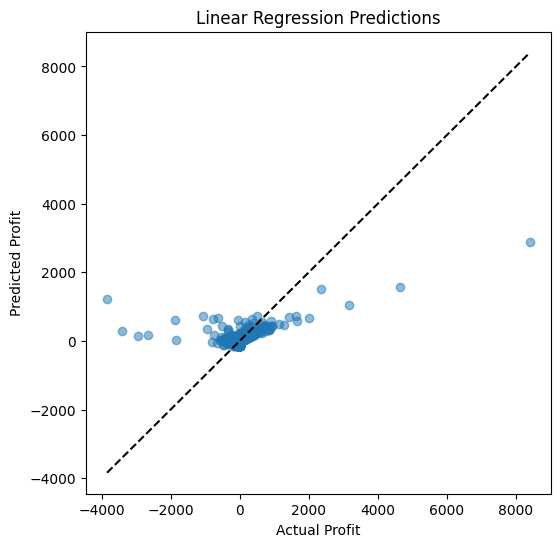

In [9]:
# select features for profit prediction
target = 'Profit'
features = ['Sales', 'Quantity', 'Discount']

# drop rows with missing values in relevant columns
reg_df = df[features + [target]].dropna()
X = reg_df[features]
y = reg_df[target]

# split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25, 
                                                    random_state=42)

# fit linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
print("Predictions:", y_pred)

# evaluation metrics
print("MSE:", mean_squared_error(y_test, y_pred))
print("R^2:", r2_score(y_test, y_pred))
print("Intercept:", lr.intercept_)
print("Slope:", lr.coef_)
print

# feature importance via coefficients
coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': lr.coef_
}).sort_values('coefficient', key=abs, ascending=False)
print("\nFeature importances (by absolute coefficient):")
print(coef_df)

# scatter predictions vs truth
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.title('Linear Regression Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.show()
